# COVID-19 Hospitalization Prediction

Goal: predict whether a patient is hospitalized.


# Task

Binary classification using `TIPO_PACIENTE`:

- `1`: outpatient
- `2`: hospitalized

Avoid leakage variables like ICU, intubation, and death date.


In [32]:
import pandas as pd
import numpy as np



RANDOM_STATE = 42


## Load data


In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/mexico_covid19.csv", encoding="latin-1")

print("Rows, columns:", df.shape)
df.head()


Rows, columns: (263007, 41)


,id,FECHA_ARCHIVO,ID_REGISTRO,ENTIDAD_UM,ENTIDAD_RES,RESULTADO,DELAY,ENTIDAD_REGISTRO,ENTIDAD,ABR_ENT,FECHA_ACTUALIZACION,ORIGEN,SECTOR,SEXO,ENTIDAD_NAC,MUNICIPIO_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,NACIONALIDAD,EMBARAZO,HABLA_LENGUA_INDIG,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,9269,2020-04-12,00011f,25,25,2,0,25,Sinaloa,SL,2020-04-19,2,12,2,25,13.0,1,2020-03-20,2020-03-12,9999-99-99,97,2,74,1,97,2,1,2,2,2,1,2,2,1,2,2,2,99,MÃÂ©xico,97,97
1,33333,2020-04-12,00014e,14,14,2,0,14,Jalisco,JC,2020-04-19,1,4,1,16,98.0,2,2020-03-30,2020-03-30,9999-99-99,2,2,71,1,2,2,1,1,2,2,1,2,2,1,2,1,99,99,MÃÂ©xico,97,2
2,35483,2020-04-12,000153,8,8,1,0,8,Chihuahua,CH,2020-04-19,1,4,2,8,19.0,2,2020-04-02,2020-03-24,9999-99-99,2,1,50,1,97,2,2,2,2,2,2,2,2,2,2,2,99,99,MÃÂ©xico,97,2
3,7062,2020-04-12,0001b6,9,15,1,0,9,Ciudad de Mexico,DF,2020-04-19,2,4,1,15,33.0,1,2020-04-01,2020-03-26,9999-99-99,97,2,25,1,2,2,2,2,2,2,2,2,2,1,2,2,99,99,MÃÂ©xico,97,97
4,23745,2020-04-12,0001c1,9,9,2,0,9,Ciudad de Mexico,DF,2020-04-19,1,4,1,99,15.0,1,2020-04-07,2020-04-06,9999-99-99,97,2,28,1,2,2,2,2,2,2,2,2,2,2,2,2,99,99,MÃÂ©xico,97,97


## Column meanings

English meanings for all original columns, in the same order as the dataset.


In [3]:
data_dictionary = pd.DataFrame([
    ("id", "row id / index", "not a real patient feature"),
    ("FECHA_ARCHIVO", "file date", "date"),
    ("ID_REGISTRO", "case record id", "identifier"),
    ("ENTIDAD_UM", "state of medical unit", "location"),
    ("ENTIDAD_RES", "state of residence", "location"),
    ("RESULTADO", "COVID test result", "test information"),
    ("DELAY", "reporting delay", "administrative"),
    ("ENTIDAD_REGISTRO", "state where case was registered", "location"),
    ("ENTIDAD", "state name", "location"),
    ("ABR_ENT", "state abbreviation", "location"),
    ("FECHA_ACTUALIZACION", "data update date", "date"),
    ("ORIGEN", "reporting origin", "administrative"),
    ("SECTOR", "healthcare sector", "administrative"),
    ("SEXO", "sex", "demographic"),
    ("ENTIDAD_NAC", "state of birth", "demographic/location"),
    ("MUNICIPIO_RES", "municipality of residence", "location"),
    ("TIPO_PACIENTE", "patient type: outpatient or hospitalized", "target"),
    ("FECHA_INGRESO", "admission / medical visit date", "date"),
    ("FECHA_SINTOMAS", "symptom onset date", "date"),
    ("FECHA_DEF", "death date", "leakage"),
    ("INTUBADO", "intubated", "leakage"),
    ("NEUMONIA", "pneumonia", "possible leakage"),
    ("EDAD", "age", "demographic"),
    ("NACIONALIDAD", "nationality: Mexican or foreign", "demographic"),
    ("EMBARAZO", "pregnancy", "clinical"),
    ("HABLA_LENGUA_INDIG", "speaks an Indigenous language", "demographic"),
    ("DIABETES", "diabetes", "comorbidity"),
    ("EPOC", "COPD", "comorbidity"),
    ("ASMA", "asthma", "comorbidity"),
    ("INMUSUPR", "immunosuppressed", "comorbidity"),
    ("HIPERTENSION", "hypertension", "comorbidity"),
    ("OTRA_COM", "other comorbidity", "comorbidity"),
    ("CARDIOVASCULAR", "cardiovascular disease", "comorbidity"),
    ("OBESIDAD", "obesity", "comorbidity"),
    ("RENAL_CRONICA", "chronic kidney disease", "comorbidity"),
    ("TABAQUISMO", "smoking", "risk factor"),
    ("OTRO_CASO", "contact with another COVID case", "exposure"),
    ("MIGRANTE", "migrant", "demographic"),
    ("PAIS_NACIONALIDAD", "country of nationality", "demographic"),
    ("PAIS_ORIGEN", "country of origin", "demographic"),
    ("UCI", "ICU admission", "leakage"),
], columns=["column", "meaning", "note"])

data_dictionary


,column,meaning,note
0,id,row id / index,not a real patient feature
1,FECHA_ARCHIVO,file date,date
2,ID_REGISTRO,case record id,identifier
3,ENTIDAD_UM,state of medical unit,location
4,ENTIDAD_RES,state of residence,location
5,RESULTADO,COVID test result,test information
6,DELAY,reporting delay,administrative
7,ENTIDAD_REGISTRO,state where case was registered,location
8,ENTIDAD,state name,location
9,ABR_ENT,state abbreviation,location


For many binary medical columns, `1` usually means yes, `2` means no, and values like `97`, `98`, `99` mean not applicable or unknown.


## Target


Binary classification. The original target column is `TIPO_PACIENTE`:

- `1`: outpatient
- `2`: hospitalized

I convert it into `hospitalized`:

- `0`: outpatient
- `1`: hospitalized

In [4]:
df["hospitalized"] = (df["TIPO_PACIENTE"] == 2).astype(int)

class_counts = df["hospitalized"].value_counts().rename(index={0: "not hospitalized", 1: "hospitalized"})
class_percentages = df["hospitalized"].value_counts(normalize=True).rename(index={0: "not hospitalized", 1: "hospitalized"}) * 100

pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages.round(2)
})


,count,percentage
hospitalized,,
not hospitalized,200838,76.36
hospitalized,62169,23.64


The target is imbalanced, so accuracy alone will not be enough.

## Initial feature set

We start with demographic and comorbidity(基础病) variables. `NEUMONIA` is kept separate because it may cause leakage.

In [5]:
base_features = [
    "SEXO",
    "EDAD",
    "DIABETES",
    "EPOC",
    "ASMA",
    "INMUSUPR",
    "HIPERTENSION",
    "OTRA_COM",
    "CARDIOVASCULAR",
    "OBESIDAD",
    "RENAL_CRONICA",
    "TABAQUISMO",
    "OTRO_CASO"
]

suspicious_features = [
    "NEUMONIA"
]

target = "hospitalized"

In [6]:
feature_summary = []

for col in base_features + suspicious_features:
    counts = df[col].value_counts(dropna=False).sort_index()
    feature_summary.append({
        "feature": col,
        "unique_values": list(counts.index),
        "n_unique": df[col].nunique(dropna=False),
        "missing_or_unknown_count": df[col].isin([97, 98, 99]).sum()
    })

pd.DataFrame(feature_summary)

,feature,unique_values,n_unique,missing_or_unknown_count
0,SEXO,"[1, 2]",2,0
1,EDAD,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",117,121
2,DIABETES,"[1, 2, 98]",3,1011
3,EPOC,"[1, 2, 98]",3,931
4,ASMA,"[1, 2, 98]",3,923
5,INMUSUPR,"[1, 2, 98]",3,1038
6,HIPERTENSION,"[1, 2, 98]",3,938
7,OTRA_COM,"[1, 2, 98]",3,1344
8,CARDIOVASCULAR,"[1, 2, 98]",3,961
9,OBESIDAD,"[1, 2, 98]",3,962


## Prepare selected features

I create a smaller dataset with the selected features and the target. Unavailable values such as `98` and `99` are treated as missing.

In [7]:
# Keep only the selected base features and the target
model_df = df[base_features + [target]].copy()

# For most binary medical variables:
# 1 = yes, 2 = no, 98/99 = unknown or missing
unknown_codes = [97, 98, 99]

# Replace unknown codes with NaN so they are treated as missing values later
for col in base_features:
    if col != "EDAD": # age
        model_df[col] = model_df[col].replace(unknown_codes, np.nan)

# Check the cleaned data
model_df.head()

,SEXO,EDAD,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,hospitalized
0,2,74,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,0
1,1,71,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,NaN,1
2,2,50,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,1
3,1,25,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,NaN,0
4,1,28,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,0


In [8]:
# Check how many missing values each selected feature has
missing_summary = pd.DataFrame({
    "missing_count": model_df[base_features].isna().sum(),
    "missing_percent": (model_df[base_features].isna().mean() * 100).round(2)
})

missing_summary

,missing_count,missing_percent
SEXO,0,0.00
EDAD,0,0.00
DIABETES,1011,0.38
EPOC,931,0.35
ASMA,923,0.35
INMUSUPR,1038,0.39
HIPERTENSION,938,0.36
OTRA_COM,1344,0.51
CARDIOVASCULAR,961,0.37
OBESIDAD,962,0.37


## *Leakage audit

The prediction moment is assumed to be the initial clinical evaluation.
Before modeling, I check important or potentially problematic variables.

In [9]:
# Create a small table to record whether important variables are safe to use
leakage_audit = pd.DataFrame([
    {
        "variable": "EDAD",
        "meaning": "age",
        "available_at_prediction_time": "yes",
        "included": "yes",
        "reason": "Baseline demographic information."
    },
    {
        "variable": "SEXO",
        "meaning": "sex",
        "available_at_prediction_time": "yes",
        "included": "yes",
        "reason": "Baseline demographic information."
    },
    {
        "variable": "Comorbidities",
        "meaning": "diabetes, asthma, hypertension, epoc etc.",
        "available_at_prediction_time": "yes",
        "included": "yes",
        "reason": "Usually known from patient history."
    },
    {
        "variable": "OTRO_CASO",
        "meaning": "contact with another COVID case",
        "available_at_prediction_time": "probably yes",
        "included": "yes",
        "reason": "Exposure history may be asked during initial evaluation, but it has many unknown values."
    },
    {
        "variable": "NEUMONIA",
        "meaning": "pneumonia",
        "available_at_prediction_time": "unclear",
        "included": "no for base model",
        "reason": "Could reflect disease severity or information recorded after evaluation, so it may cause leakage."
    },
    {
        "variable": "INTUBADO",
        "meaning": "intubated",
        "available_at_prediction_time": "no",
        "included": "no",
        "reason": "This is downstream of severe hospitalization."
    },
    {
        "variable": "UCI",
        "meaning": "ICU admission",
        "available_at_prediction_time": "no",
        "included": "no",
        "reason": "This is an outcome after admission."
    },
    {
        "variable": "FECHA_DEF",
        "meaning": "death date",
        "available_at_prediction_time": "no",
        "included": "no",
        "reason": "This is only known after the outcome."
    }
])

leakage_audit

,variable,meaning,available_at_prediction_time,included,reason
0,EDAD,age,yes,yes,Baseline demographic information.
1,SEXO,sex,yes,yes,Baseline demographic information.
2,Comorbidities,"diabetes, asthma, hypertension, epoc etc.",yes,yes,Usually known from patient history.
3,OTRO_CASO,contact with another COVID case,probably yes,yes,Exposure history may be asked during initial e...
4,NEUMONIA,pneumonia,unclear,no for base model,Could reflect disease severity or information ...
5,INTUBADO,intubated,no,no,This is downstream of severe hospitalization.
6,UCI,ICU admission,no,no,This is an outcome after admission.
7,FECHA_DEF,death date,no,no,This is only known after the outcome.


## *EDA plots

- Target distribution: shows class imbalance.
- Hospitalization rate by age group
- Hospitalization rate by comorbidity: checks which health conditions are associated with hospitalization.
- Missing values in selected features

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

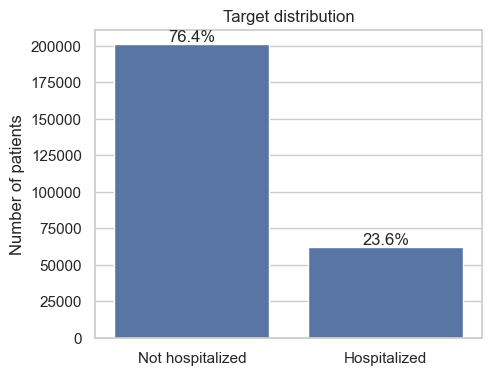

In [11]:
# Plot the number of hospitalized vs not hospitalized patients
# Count target classes and calculate percentages
target_counts = model_df[target].value_counts().sort_index()
target_percentages = model_df[target].value_counts(normalize=True).sort_index() * 100

# Plot target distribution as a bar chart
plt.figure(figsize=(5, 4))
ax = sns.barplot(
    x=target_counts.index.map({0: "Not hospitalized", 1: "Hospitalized"}),
    y=target_counts.values
)

# Add percentage labels on top of bars
for i, count in enumerate(target_counts.values):
    percentage = target_percentages.iloc[i]
    ax.text(
        i,
        count,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Target distribution")
plt.ylabel("Number of patients")
plt.xlabel("")
plt.show()

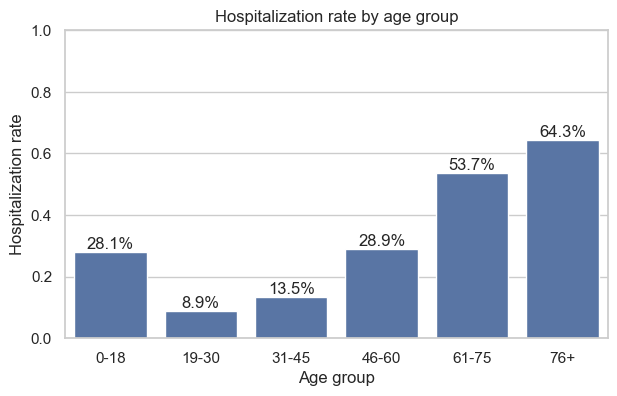

In [12]:
# Group ages into bins so the pattern is easier to see
model_df["age_group"] = pd.cut(
    model_df["EDAD"],
    bins=[0, 18, 30, 45, 60, 75, 120],
    labels=["0-18", "19-30", "31-45", "46-60", "61-75", "76+"],
    include_lowest=True
)

# Calculate hospitalization rate in each age group
age_hosp_rate = model_df.groupby("age_group", observed=True)[target].mean().reset_index()

# Plot hospitalization rate by age group
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=age_hosp_rate,
    x="age_group",
    y=target
)

# Add percentage labels on top of bars
for i, row in age_hosp_rate.iterrows():
    ax.text(
        i,
        row[target],
        f"{row[target] * 100:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Hospitalization rate by age group")
plt.xlabel("Age group")
plt.ylabel("Hospitalization rate")
plt.ylim(0, 1)
plt.show()

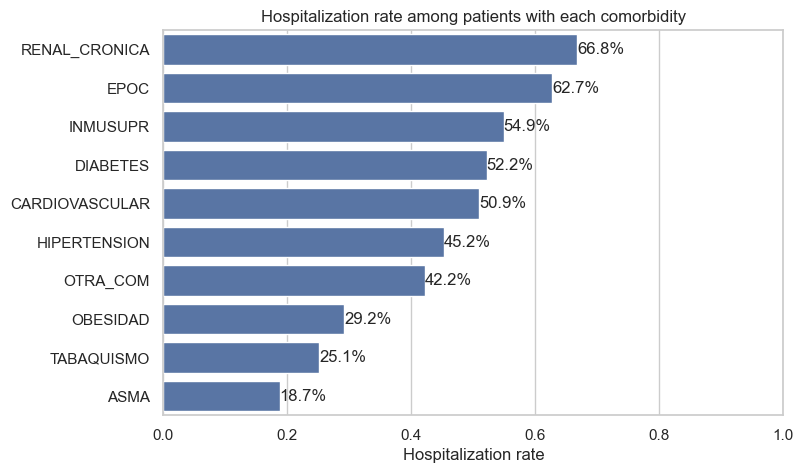

In [13]:
# Compare hospitalization rates among patients who have each comorbidity
comorbidity_features = [
    "DIABETES",
    "EPOC",
    "ASMA",
    "INMUSUPR",
    "HIPERTENSION",
    "OTRA_COM",
    "CARDIOVASCULAR",
    "OBESIDAD",
    "RENAL_CRONICA",
    "TABAQUISMO" #smoking
]

comorbidity_rates = []

for col in comorbidity_features:
    # For these columns, 1 means yes
    patients_with_condition = model_df[model_df[col] == 1]

    comorbidity_rates.append({
        "feature": col,
        "hospitalization_rate": patients_with_condition[target].mean(),
        "count": len(patients_with_condition)
    })

comorbidity_rates = pd.DataFrame(comorbidity_rates).sort_values(
    "hospitalization_rate",
    ascending=False
)

# Plot hospitalization rate by comorbidity
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=comorbidity_rates,
    y="feature",
    x="hospitalization_rate"
)

# Add percentage labels to the right of bars
for i, row in comorbidity_rates.reset_index(drop=True).iterrows():
    ax.text(
        row["hospitalization_rate"],
        i,
        f"{row['hospitalization_rate'] * 100:.1f}%",
        va="center",
        ha="left"
    )

plt.title("Hospitalization rate among patients with each comorbidity")
plt.xlabel("Hospitalization rate")
plt.ylabel("")
plt.xlim(0, 1)
plt.show()

Note: Meaning of the percentages eg. among patients with diabetes, what percentage were hospitalized?

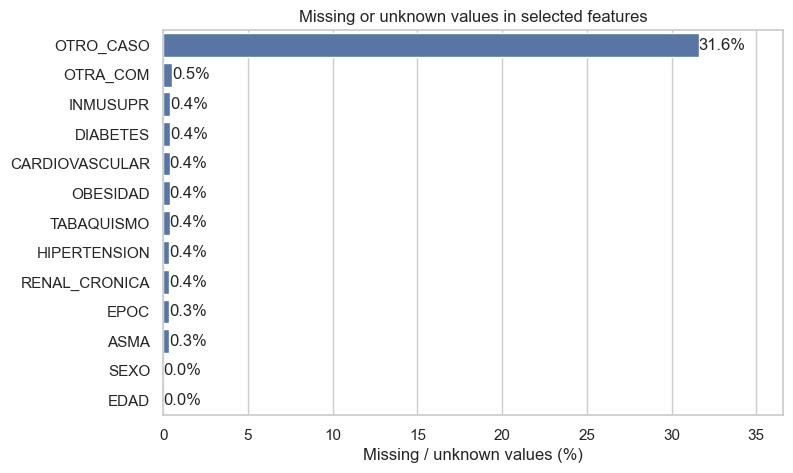

In [14]:
# Prepare missing-value data for plotting
# missing_summary was created earlier from model_df
missing_plot_data = missing_summary.reset_index().rename(columns={"index": "feature"})

# Sort features by missing percentage
missing_plot_data = missing_plot_data.sort_values("missing_percent", ascending=False)

# Plot missing/unknown percentage for each selected feature
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=missing_plot_data,
    x="missing_percent",
    y="feature"
)

# Add percentage labels next to the bars
for i, row in missing_plot_data.reset_index(drop=True).iterrows():
    ax.text(
        row["missing_percent"],
        i,
        f"{row['missing_percent']:.1f}%",
        va="center",
        ha="left"
    )

plt.title("Missing or unknown values in selected features")
plt.xlabel("Missing / unknown values (%)")
plt.ylabel("")
plt.xlim(0, max(missing_plot_data["missing_percent"]) + 5)
plt.show()

The EDA shows that the target is imbalanced: most patients were not hospitalized. 

Hospitalization rate differs across age groups: it is relatively high for the youngest group, lower for young adults, and higher again among older patients. 

some comorbidities are associated with higher hospitalization rates.

Most selected variables have few unknown values. `OTRO_CASO` has many unknown values, so I may later compare models with and without this feature.

## Train/test split

80/20, stratified split

The test set is kept separate and will only be used for the final evaluation.

In [15]:
from sklearn.model_selection import train_test_split

# Define X and y
# X contains only the selected input features
# y is the binary hospitalization target
X = model_df[base_features]
y = model_df[target]

# Use a stratified split so the hospitalization rate is similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y #split the data while preserving the target class distribution
)

# Check the sizes of the split
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 210405
Test rows: 52602


In [16]:
# Check whether the target distribution is similar in train and test sets
split_check = pd.DataFrame({
    "full_data": y.value_counts(normalize=True).sort_index(),
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
})

split_check.index = ["not hospitalized", "hospitalized"]
split_check.round(3)

,full_data,train,test
not hospitalized,0.764,0.764,0.764
hospitalized,0.236,0.236,0.236


I use a stratified random split because the target is imbalanced. This keeps the hospitalization rate approximately the same in the training and test sets.

# Models

In [28]:
# Helper function to evaluate a binary classification model
# Positive class: hospitalized = 1
def evaluate_model(model_name, y_true, y_pred, y_proba):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

In [31]:
# Import models, preprocessing tools, and evaluation metrics
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

## Baseline model

As a simple reference, I use a **majority-class classifier**. It always predicts the most common class in the training data.

In [20]:
# Import baseline model
from sklearn.dummy import DummyClassifier

# Create a majority-class baseline model
# This model always predicts the most frequent class in the training set
baseline_model = DummyClassifier(strategy="most_frequent")

# Fit the baseline only on the training data
baseline_model.fit(X_train, y_train)

# Predict labels on the test set
baseline_pred = baseline_model.predict(X_test)

# Predict probabilities on the test set
# The probability for class 1 is needed for ROC-AUC
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

In [25]:
# Evaluate the baseline model
baseline_results = {
    "model": "majority-class classifier",
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, baseline_proba)
}

pd.DataFrame([baseline_results])

,model,accuracy,precision,recall,f1,roc_auc
0,majority-class classifier,0.763621,0.0,0.0,0.0,0.5


The baseline has relatively high accuracy because most patients were not hospitalized, but it never identifies hospitalized patients. This shows why accuracy alone is not enough.

## Logistic regression

Logistic regression is the first real model. It is simple and interpretable, so it is useful as a starting point.

In [29]:
# Build a logistic regression pipeline
# Imputer fills missing values
# StandardScaler standardizes numeric values
# Logistic regression then fits the classifier
logreg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Fit the model only on the training data
logreg_model.fit(X_train, y_train)

# Predict class labels on the test set
logreg_pred = logreg_model.predict(X_test)

# Predict probabilities for the positive class: hospitalized = 1
logreg_proba = logreg_model.predict_proba(X_test)[:, 1]

In [30]:
# Evaluate logistic regression
logreg_results = evaluate_model(
    "Logistic regression",
    y_test,
    logreg_pred,
    logreg_proba
)

# Compare with the majority baseline
pd.DataFrame([baseline_results, logreg_results]).round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,majority-class classifier,0.764,0.000,0.000,0.000,0.500
1,Logistic regression,0.791,0.643,0.261,0.371,0.748


In [33]:
# Confusion matrix for logistic regression
# Rows are actual classes, columns are predicted classes
logreg_cm = confusion_matrix(y_test, logreg_pred)

pd.DataFrame(
    logreg_cm,
    index=["Actual not hospitalized", "Actual hospitalized"],
    columns=["Predicted not hospitalized", "Predicted hospitalized"]
)

,Predicted not hospitalized,Predicted hospitalized
Actual not hospitalized,38366,1802
Actual hospitalized,9188,3246


Compared with the majority baseline, logistic regression should be more useful as it identifies at least some hospitalized patients.